# Product Performance Analysis Across Regions and Time using OLAP Techniques

This notebook demonstrates slicing, dicing, and drill-down operations on sales data using Python and SQLite, with visualizations to explore product performance by region and over time.

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Connect to the local database
db_path = "/Users/kyleroof/Projects/smart-store-kyleroof/data/dw/smart_sales.db"
conn = sqlite3.connect(db_path)

In [5]:
# Load tables
df_customer = pd.read_sql("SELECT * FROM customer", conn)
df_product = pd.read_sql("SELECT * FROM product", conn)
df_sale = pd.read_sql("SELECT * FROM sale", conn)

In [6]:
# Merge tables
df = df_sale.merge(df_customer, on="customer_id", how="left").merge(df_product, on="product_id", how="left")

# Convert date and create time dimension
df["sale_date"] = pd.to_datetime(df["sale_date"])
df["year_month"] = df["sale_date"].dt.to_period("M").astype(str)

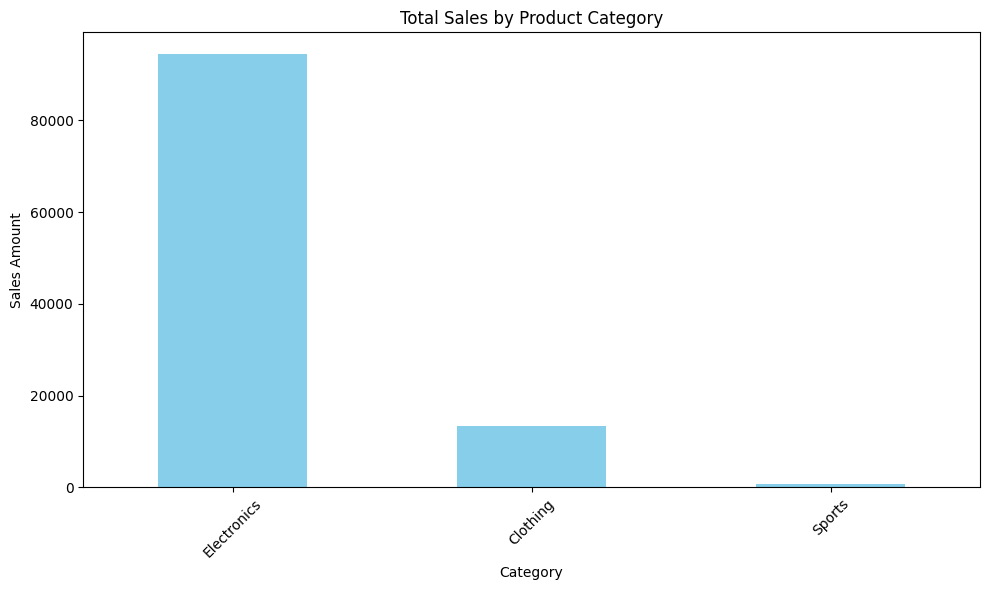

In [7]:
sales_by_category = df.groupby("category")["sale_amount"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sales_by_category.plot(kind="bar", color="skyblue")
plt.title("Total Sales by Product Category")
plt.ylabel("Sales Amount")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

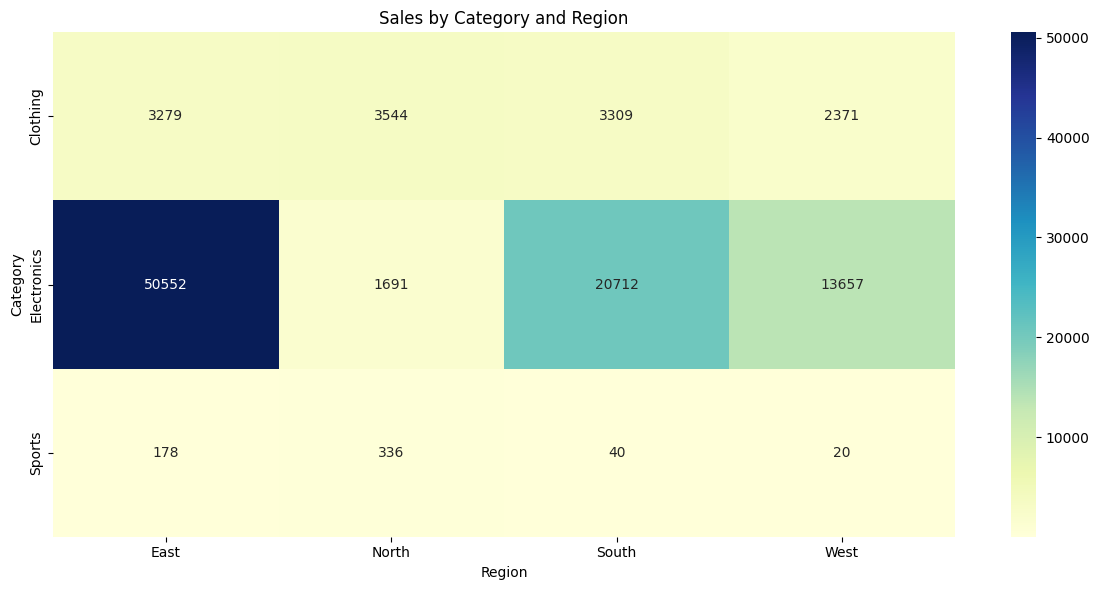

In [8]:
sales_cat_region = df.groupby(["category", "region"])["sale_amount"].sum().unstack().fillna(0)

plt.figure(figsize=(12, 6))
sns.heatmap(sales_cat_region, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Sales by Category and Region")
plt.ylabel("Category")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

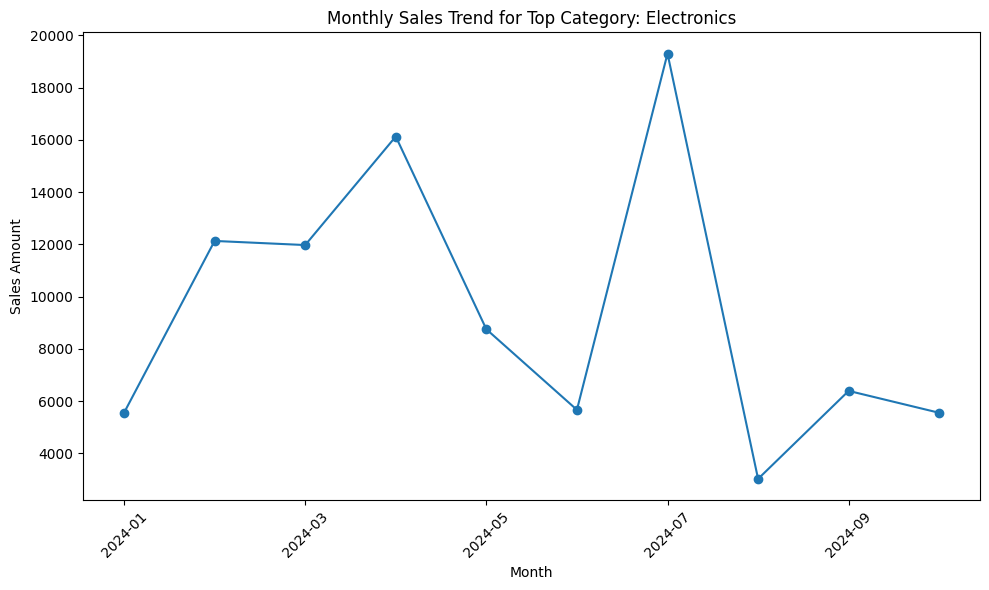

In [9]:
top_category = sales_by_category.idxmax()
monthly_sales_top = df[df["category"] == top_category].groupby("year_month")["sale_amount"].sum()

plt.figure(figsize=(10, 6))
monthly_sales_top.plot(marker="o")
plt.title(f"Monthly Sales Trend for Top Category: {top_category}")
plt.ylabel("Sales Amount")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
conn.close()